# The Training-Ready ERA5: From Curated Dataset to Model Input


**Author**: Harrison Cook

*This notebook was last tested and operational on 02/06/2026. Please [report any issues](https://github.com/ecmwf-training/2026-ml-esm-training/issues).*

<!-- :::{admonition} About
:class: note, dropdown -->
This notebook was developed for the DestinE [2026 Machine Learning for Earth System Modelling Course](https://learning.ecmwf.int/course/view.php?id=99). It provides a hands-on introduction to the Anemoi training-ready ERA5 dataset. We cover dataset exploration, normalisation statistics, the Zarr format, and model input preparation.
<!-- ::: -->

<!-- :::{admonition} Running this notebook
:class: tip, dropdown -->
This notebook can be run/accessed on the following free online platforms. Please note they are not officially supported by or linked with ECMWF.

[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecmwf-training/2026-ml-esm-training/blob/main/m3/using_era5_anemoi_solved.ipynb)
[![kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ecmwf-training/2026-ml-esm-training/blob/main/m3/using_era5_anemoi_solved.ipynb)
[![binder](https://mybinder.org/badge.svg)](https://mybinder.org/v2/gh/ecmwf-training/2026-ml-esm-training/main?labpath=m3/using_era5_anemoi_solved.ipynb)
[![github](https://img.shields.io/badge/Open%20in-GitHub-black?logo=github)](https://github.com/ecmwf-training/2026-ml-esm-training/blob/main/m3/using_era5_anemoi_solved.ipynb)
<!-- 
::: -->

## Introduction

In this notebook you will explore the result of the pipeline that transfers raw ERA5 data into an ML ready dataset. That dataset is the [Anemoi training-ready ERA5 dataset](https://www.ecmwf.int/en/about/media-centre/aifs-blog/2025/introducing-anemoi-training-ready-version-era5).

**This is not "just ERA5 in a different format."** It is a curated subset with consistent variables, subsampled time frequency, pre-computed normalisation statistics and zarr-based storage. The goal of the training-ready ERA5 dataset is to reduce the training loop to pure computation: We would like to minimise the impact of I/O and preprocessing bottlenecks, to allow large-scale multi-GPU training.

## In this notebook

In this notebook we will take you throught the following steps:
- Preparing the environment
- Loading the data: the era5 anemoi dataset
- Exploring the normalisation statistics that are included in the dataset
- Exploring the Zarr format
- Moving from training dataset to model input 

## Prepare your environment

The following packages are used to process and model the data:
- `matplotlib`: for plotting
- `numpy`: for handling arrays and mathematical functions
- `anemoi-datasets` to point us to named datasets from ECMWF's registry. We will use it to open the Anemoi training-ready ERA5 dataset.
- `time`
- `torch` for building and training a transformer neural network
- `einops`

In [1]:
%pip install -q -r https://raw.githubusercontent.com/ecmwf-training/2026-ml-esm-training/main/m3/requirements.txt

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [2 lines of output]
      CRITICAL:root:A GDAL API version must be specified. Provide a path to gdal-config using a GDAL_CONFIG environment variable or use a GDAL_VERSION environment variable.
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
ERROR: Failed to build 'fiona' when getting requirements to build wheel
Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from anemoi.datasets import open_dataset
import time

import torch
from einops import rearrange

Let us first visualise what the differences are between the Raw and Training-Ready versions of ERA5. That is: What exactly does the `anemoi-datasets` build pipeline do to the ERA5 we know?

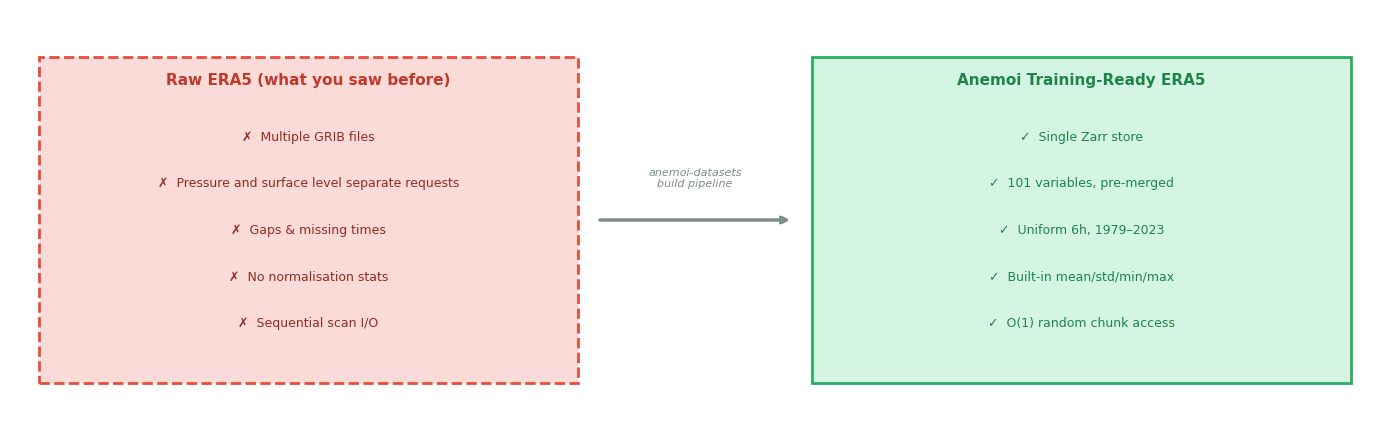

In [3]:
# Diagram: Raw ERA5 vs Training-Ready ERA5

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4.5)
ax.axis('off')

# --- Left: Raw ERA5 (pain) ---
raw_box = plt.Rectangle((0.3, 0.5), 5.5, 3.5, fill=True, facecolor='#fadbd8',
                         edgecolor='#e74c3c', linewidth=2, linestyle='--')
ax.add_patch(raw_box)
ax.text(3.05, 3.7, 'Raw ERA5 (what you saw before)', ha='center',
        fontsize=11, fontweight='bold', color='#c0392b')

raw_items = [
    'Multiple GRIB files',
    'Pressure and surface level separate requests',
    'Gaps & missing times',
    'No normalisation stats',
    'Sequential scan I/O',
]
for i, item in enumerate(raw_items):
    ax.text(3.05, 3.1 - i * 0.5, f'\u2717  {item}', ha='center', fontsize=9, color='#922b21')

# --- Right: Training-Ready ERA5 (solution) ---
ready_box = plt.Rectangle((8.2, 0.5), 5.5, 3.5, fill=True, facecolor='#d5f5e3',
                           edgecolor='#27ae60', linewidth=2)
ax.add_patch(ready_box)
ax.text(10.95, 3.7, 'Anemoi Training-Ready ERA5', ha='center',
        fontsize=11, fontweight='bold', color='#1e8449')

ready_items = [
    'Single Zarr store',
    '101 variables, pre-merged',
    'Uniform 6h, 1979\u20132023',
    'Built-in mean/std/min/max',
    'O(1) random chunk access',
]
for i, item in enumerate(ready_items):
    ax.text(10.95, 3.1 - i * 0.5, f'\u2713  {item}', ha='center', fontsize=9, color='#1e8449')

# Arrow between them
ax.annotate('', xy=(8.0, 2.25), xytext=(6.0, 2.25),
            arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=2.5))
ax.text(7.0, 2.6, 'anemoi-datasets\nbuild pipeline', ha='center', fontsize=8,
        color='#7f8c8d', fontstyle='italic')

plt.tight_layout()
plt.show()

As you can see, we have transformed raw ERA5 into a dataset with:
- A single Zarr store: I.e. all the data can be retrieved from a single "store" with a consistent set of metadata, rather than a large number of independent grid files
- 101 variables: a fixed set of atmospheric (pressure-level) and surface fields has been extracted and merged together, so that a single dataset is produced with just variables we wish to forecast
- Subsampled temporal frequency: Gaps in ERA5 (1979-2023) are filled, and the data is sub-sampled to the 6-hourly time steps we envision forecasting with
- Pre-computed normalisation statistics: mean, std, min, max is added to the dataset metadata so you don't have to compute it yourself
- Zarr-based storage: The dataset is chunked for efficient random access along the time axis, designed for parallel I/O

## 1. Opening the Dataset

We open the dataset with the dedicated `anemoi-datasets.open_dataset` function:

In [4]:
ds = open_dataset('https://data.ecmwf.int/anemoi-datasets/era5-o96-1979-2023-6h-v8.zarr')
ds

zarr https://data.ecmwf.int/anemoi-datasets/era5-o96-1979-2023-6h-v8.zarr


### Task: Take a look at the data.

Use the empty code cell below to explore the metadata — everything a training pipeline needs to know without opening a single data chunk.
For example, print the resolution of the data, the frequency, time steps, variables included and their shapes.

Hint: the dataset has the following attributes:
- `resolution`
- `frequency`
- `grids`
- `dates`
- `variables`

In [5]:
print(f"Resolution:    {ds.resolution}")
print(f"Frequency:     {ds.frequency}")
print(f"Grid points:   {sum(ds.grids):,}")
print(f"Time steps:    {len(ds.dates):,}  ({ds.dates[0]} to {ds.dates[-1]})")
print(f"Variables:     {len(ds.variables)}")
print(f"Shape:         (dates={len(ds.dates)}, variables={len(ds.variables)}, ensemble=1, gridpoints={sum(ds.grids)})")

Resolution:    O96
Frequency:     6:00:00
Grid points:   40,320
Time steps:    65,744  (1979-01-01T00:00:00 to 2023-12-31T18:00:00)
Variables:     101
Shape:         (dates=65744, variables=101, ensemble=1, gridpoints=40320)


In [6]:
# The varibales are not everything in ERA5, but the variables that matter for forecasting
print("Variables in the dataset:")
for i, v in enumerate(ds.variables):
    print(f"  {i:3d}. {v}")

Variables in the dataset:
    0. 10u
    1. 10v
    2. 2d
    3. 2t
    4. cos_julian_day
    5. cos_latitude
    6. cos_local_time
    7. cos_longitude
    8. cp
    9. insolation
   10. lsm
   11. msl
   12. q_100
   13. q_1000
   14. q_150
   15. q_200
   16. q_250
   17. q_300
   18. q_400
   19. q_50
   20. q_500
   21. q_600
   22. q_700
   23. q_850
   24. q_925
   25. sdor
   26. sin_julian_day
   27. sin_latitude
   28. sin_local_time
   29. sin_longitude
   30. skt
   31. slor
   32. sp
   33. t_100
   34. t_1000
   35. t_150
   36. t_200
   37. t_250
   38. t_300
   39. t_400
   40. t_50
   41. t_500
   42. t_600
   43. t_700
   44. t_850
   45. t_925
   46. tcw
   47. tp
   48. u_100
   49. u_1000
   50. u_150
   51. u_200
   52. u_250
   53. u_300
   54. u_400
   55. u_50
   56. u_500
   57. u_600
   58. u_700
   59. u_850
   60. u_925
   61. v_100
   62. v_1000
   63. v_150
   64. v_200
   65. v_250
   66. v_300
   67. v_400
   68. v_50
   69. v_500
   70. v_600
   71. v_

## 2. Built-in Normalisation Statistics

The dataset comes with pre-computed statistics over the full training period. That means that if you want to train based on ERA5, you do not need to scan the entire archive before training to compute normalisation statistics. It also intends to nudge all users towards using the same normalisation. Let's therefore introduce to you these statistics.

The statistics are stored per variable, and are computed over the whole data domain of that variable. The code cell below plots their mean and standard deviation:

In [7]:
stats = ds.statistics
print(f"Statistics keys: {list(stats.keys())}")
print(f"Shape of each statistic array: {stats['mean'].shape}  (one value per variable)")
print(f"Example — first 5 variables:")
print(f"  {'Variable':<20} {'Mean':>12} {'Std':>12}")
print(f"  {'-'*20} {'-'*12} {'-'*12}")
for i in range(5):
    print(f"  {ds.variables[i]:<20} {stats['mean'][i]:>12.4f} {stats['stdev'][i]:>12.4f}")

Statistics keys: ['mean', 'stdev', 'maximum', 'minimum']
Shape of each statistic array: (101,)  (one value per variable)
Example — first 5 variables:
  Variable                     Mean          Std
  -------------------- ------------ ------------
  10u                       -0.5607       5.3987
  10v                        0.2170       4.4688
  2d                       283.0746      15.3114
  2t                       288.0609      15.5243
  cos_julian_day             0.0000       0.7071


## 3. Zarr Storage for Training I/O

Let's now investigate the underlying Zarr store. It is chunked along the time axis. This means:
- Each training sample (a time step) is a single chunk. If you read it, you will read all the data (variables, number of grid points that that each variable is stored at), at a single time step. This is exactly what you'd need to pass through the model as a training sample, and nothing more.
- Multiple workers/GPUs can read different time steps in parallel without having to access the same data
- The data lives on disk as compressed chunks

The following code cell creates a diagram that visualises this procedure:

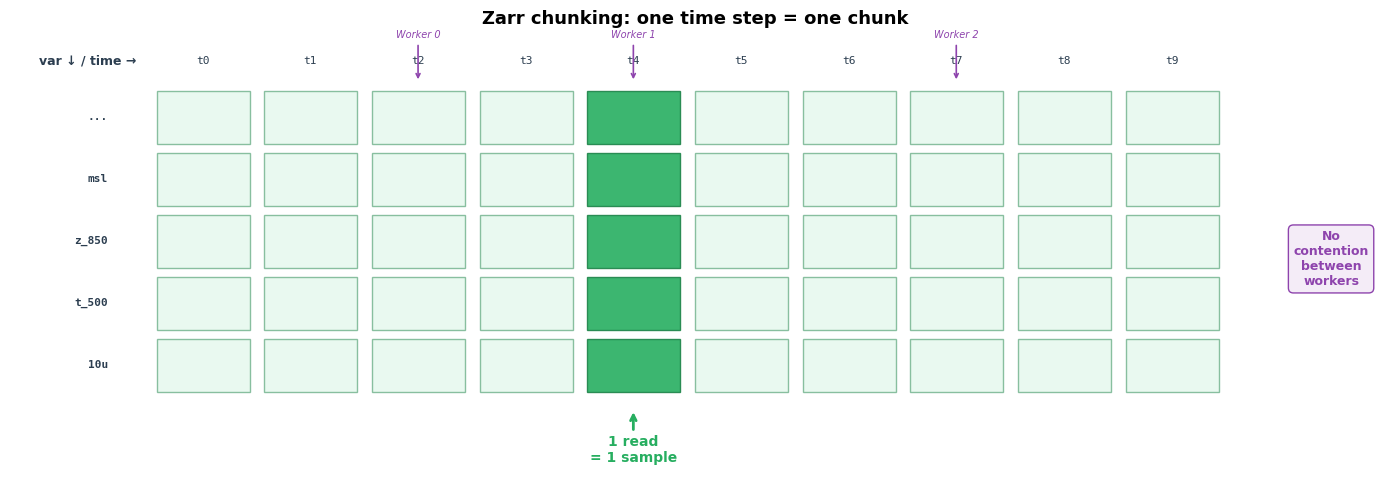

In [8]:
# Diagram: Zarr chunking — each time step is one independent chunk
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis('off')
ax.set_title('Zarr chunking: one time step = one chunk', fontsize=13, fontweight='bold', pad=10)

n_time = 10
n_vars = 5
var_labels = ['10u', 't_500', 'z_850', 'msl', '...']

# Draw the grid of chunks
for t in range(n_time):
    for v in range(n_vars):
        highlight = (t == 4)  # highlight one column = one time step
        colour = '#27ae60' if highlight else '#d5f5e3'
        alpha = 0.9 if highlight else 0.5
        rect = plt.Rectangle((1.5 + t * 1.1, 1.0 + v * 0.7), 0.95, 0.6,
                             fill=True, facecolor=colour, edgecolor='#1e8449',
                             linewidth=1, alpha=alpha)
        ax.add_patch(rect)

# Variable labels
for v, label in enumerate(var_labels):
    ax.text(1.0, 1.3 + v * 0.7, label, ha='right', va='center', fontsize=8,
            fontweight='bold', color='#2c3e50', family='monospace')

# Time labels
for t in range(n_time):
    ax.text(1.97 + t * 1.1, 4.7, f't{t}', ha='center', fontsize=8,
            color='#2c3e50', family='monospace')

ax.text(0.3, 4.7, 'var \u2193 / time \u2192', ha='left', fontsize=9, fontweight='bold', color='#2c3e50')

# Highlight annotation
ax.annotate('1 read\n= 1 sample', xy=(1.97 + 4 * 1.1, 0.8), xytext=(1.97 + 4 * 1.1, 0.2),
            fontsize=10, color='#27ae60', ha='center', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2))

# Worker annotations
for w, t_idx in enumerate([2, 4, 7]):
    ax.annotate(f'Worker {w}', xy=(1.97 + t_idx * 1.1, 4.5), xytext=(1.97 + t_idx * 1.1, 5.0),
               fontsize=7, color='#8e44ad', ha='center', fontstyle='italic',
               arrowprops=dict(arrowstyle='->', color='#8e44ad', lw=1.2))

# Side note
ax.text(13.5, 2.5, 'No\ncontention\nbetween\nworkers', ha='center', va='center',
        fontsize=9, color='#8e44ad', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f4ecf7', edgecolor='#8e44ad'))

plt.tight_layout()
plt.show()

So how long does it take to acess data from this dataset? The following cell aims to tell you. Note that the results here will depend on your network connection.

In [9]:
# Benchmark: random access across the full 45-year archive
zarr_times = []
n_trials = 50

for _ in range(n_trials):
    idx = np.random.randint(0, len(ds.dates))
    t0 = time.time()
    sample = ds[idx]
    zarr_times.append(time.time() - t0)

print(f"Random access I/O: {np.mean(zarr_times)*1000:.1f} ms +/- {np.std(zarr_times)*1000:.1f} ms per sample")
print(f"Sample shape:      {sample.shape}  (variables x gridpoints)")
print(f"\nAt this speed, a DataLoader with 4 workers can access ~{4 * 1000 / np.mean(zarr_times) / 1000:.0f}k samples/sec")

Random access I/O: 2580.8 ms +/- 180.2 ms per sample
Sample shape:      (101, 1, 40320)  (variables x gridpoints)

At this speed, a DataLoader with 4 workers can access ~2k samples/sec


## 4. From Dataset to Model Input: The Training Pipeline

Now that we have a feeling for what the Zarr dataset looks like and how to access it, let's turn our attention to how you'd feed this data into a model for training. In short, we will want to do the following steps:
1. **Time windowing**: you want to select time sequences of chronological data for autoregressive training (predicting the next time step from the previous one). In some cases, a Zarr chunk will itself be split into multiple "shards", in which case you may also wish to extract these in this step (we do not do this here).
2. **Axis rearrangement**: a GNN will often expect variables to be the last dimension of the dataset, so you have to transpose the data from `(dates, variables, ensemble, gridpoints)` to `(dates, ensemble, gridpoints, variables)`
3. **Conversion to torch tensors**: i.e. convert to the datatype that will feed into the neural network, doing so without copying where possible
4. **Normalising**: Each variable to its standardised range before entering the training procedure

Let's put these steps together and visualise the whole pipeline we need to go through to turn our Zarr dataset into model input:

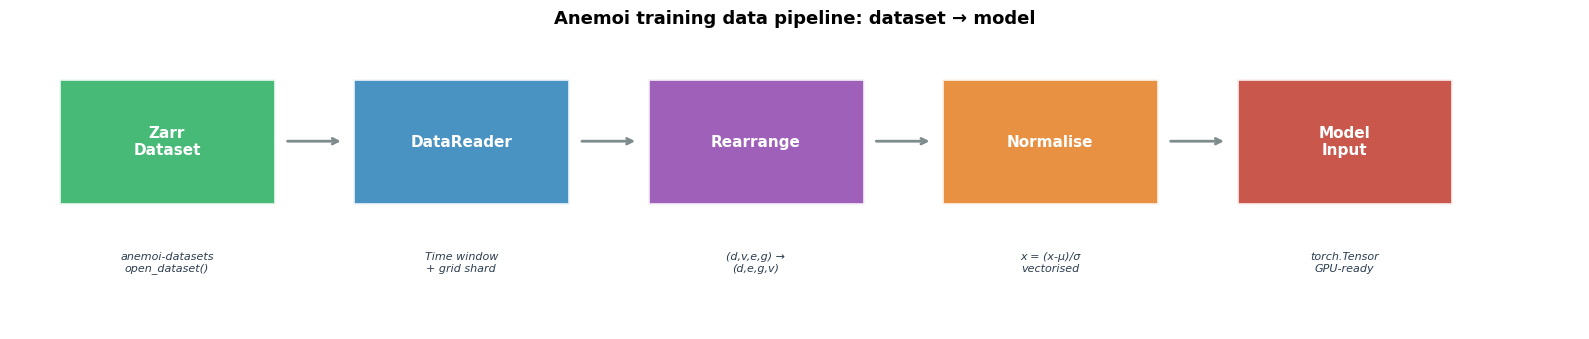

In [10]:
# Diagram: The full training data pipeline
fig, ax = plt.subplots(figsize=(16, 3.5))
ax.set_xlim(0, 16)
ax.set_ylim(0, 3.5)
ax.axis('off')

steps = [
    ('Zarr\nDataset', '#27ae60', 'anemoi-datasets\nopen_dataset()'),
    ('DataReader', '#2980b9', 'Time window\n+ grid shard'),
    ('Rearrange', '#8e44ad', '(d,v,e,g) \u2192\n(d,e,g,v)'),
    ('Normalise', '#e67e22', 'x = (x-\u03bc)/\u03c3\nvectorised'),
    ('Model\nInput', '#c0392b', 'torch.Tensor\nGPU-ready'),
]

box_w = 2.2
gap = 0.8
start_x = 0.5

for i, (label, colour, detail) in enumerate(steps):
    x = start_x + i * (box_w + gap)
    rect = plt.Rectangle((x, 1.5), box_w, 1.5, fill=True, facecolor=colour,
                         edgecolor='white', linewidth=2, alpha=0.85, zorder=2)
    ax.add_patch(rect)
    ax.text(x + box_w / 2, 2.25, label, ha='center', va='center',
            fontsize=11, fontweight='bold', color='white', zorder=3)
    ax.text(x + box_w / 2, 0.8, detail, ha='center', va='center',
            fontsize=8, color='#2c3e50', fontstyle='italic')
    if i < len(steps) - 1:
        ax.annotate('', xy=(x + box_w + gap - 0.1, 2.25), xytext=(x + box_w + 0.1, 2.25),
                    arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=2), zorder=1)

ax.set_title('Anemoi training data pipeline: dataset \u2192 model', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

The code cell below simulates the first three steps of the above procedure for a small subset of data from the dataset.

In [11]:
# Simulate a training sample: a window of consecutive time steps
# In practice, anemoi-training's DataReader.get_sample() does exactly this
rollout_steps = 4  # e.g. 1 input + 3 forecast steps
start_idx = np.random.randint(0, len(ds.dates) - rollout_steps)

# Load a temporal window — this is what the DataLoader fetches per sample
x = ds[start_idx : start_idx + rollout_steps]  # shape: (dates, variables, ensemble, gridpoints)
print(f"Window shape:   {x.shape}  — (dates, variables, ensemble, gridpoints)")

# (dates, variables, ensemble, gridpoints) -> (dates, ensemble, gridpoints, variables)
x = rearrange(x, 'dates variables ensemble gridpoints -> dates ensemble gridpoints variables')
x = torch.from_numpy(x)

print(f"Model input shape:  {x.shape}  — (dates, ensemble, gridpoints, variables)")
print(f"Dtype:              {x.dtype}")
print(f"Memory per sample:  {x.nbytes / 1024**2:.1f} MB")

Window shape:   (4, 101, 1, 40320)  — (dates, variables, ensemble, gridpoints)
Model input shape:  torch.Size([4, 1, 40320, 101])  — (dates, ensemble, gridpoints, variables)
Dtype:              torch.float32
Memory per sample:  62.1 MB


### Applying Normalisation
Now we can apply the pre-computed statistics to normalise the training sample. Let's first get the means and standard deviations:

In [12]:
# Normalise using the dataset's built-in statistics
mean = torch.from_numpy(stats['mean']).float()
std = torch.from_numpy(stats['stdev']).float()

### Task: Normalize the data

Use the code cell below to normalize the data. Fill in the calculated mean and std into the equation.

In [13]:
# Broadcasting: x is (dates, ensemble, gridpoints, variables), stats are (variables,)
x_norm = (x - mean) / std

In [14]:
#print the dataset before and after normalisation
print(f"Before normalisation — mean: {x[0, 0, :, 0].mean():.2f}, std: {x[0, 0, :, 0].std():.2f}  (variable: {ds.variables[0]})")
print(f"After normalisation  — mean: {x_norm[0, 0, :, 0].mean():.2f}, std: {x_norm[0, 0, :, 0].std():.2f}")

Before normalisation — mean: -0.77, std: 5.67  (variable: 10u)
After normalisation  — mean: -0.04, std: 1.05


## Key Takeaways

| Training-ready ERA5 feature | Why? |
|:---|:---|
| Fixed variable set | Consistent variable selection across teams |
| Uniform 6h temporal sampling | No gap-handling logic in the `DataLoader` |
| Pre-computed statistics | Reproducible normalisation without expensive first-pass scan |
| Zarr chunked along time | O(1) random access; parallel multi-worker reads |
| Reduced resolution (O96 / ~1 degree) | Half a TB instead of dozens; faster iteration cycles |

The training loop reduces to: read windowed chunks → normalise → feed to model. All the dataset engineering is done once, shared across the community, versioned and not repeated during training.

This is a dataset similar to the one that trains [ECMWF's operational AIFS system](https://www.ecmwf.int/en/about/media-centre/aifs-blog/2026/anemoi-european-framework-ai).